# 01 - EDA Détection de fraude

Objectif : analyser `data/raw/detection_fraude.csv` pour comprendre la distribution des fraudes, identifier les signaux utiles et préparer la modélisation.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "../data/raw/detection_fraude.csv"

In [2]:
df = pd.read_csv(DATA_PATH, sep=";")
print("Shape:", df.shape)
df.head()

Shape: (1048575, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
print("\nInfos generales")
print(df.info())

print("\nValeurs manquantes")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nDoublons:", df.duplicated().sum())


Infos generales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 88.0+ MB
None

Valeurs manquantes


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64


Doublons: 0


Taux de fraude global: 0.001089 (0.1089%)


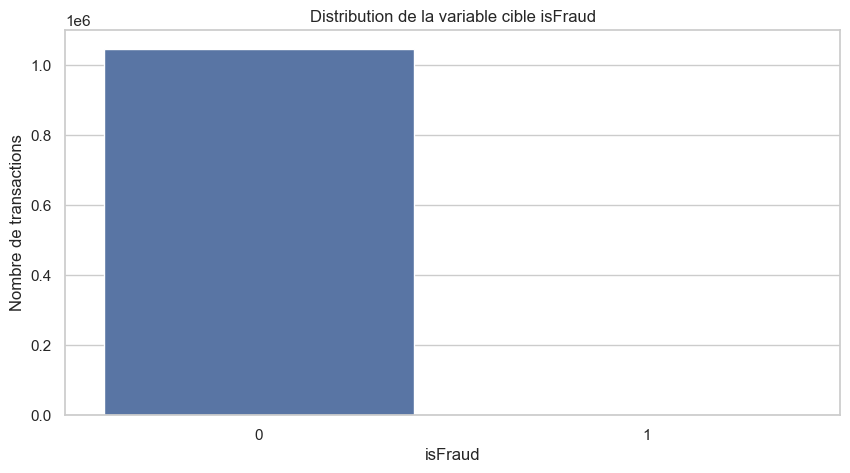

In [4]:
fraud_rate = df["isFraud"].mean()
print(f"Taux de fraude global: {fraud_rate:.6f} ({fraud_rate*100:.4f}%)")

ax = sns.countplot(data=df, x="isFraud")
ax.set_title("Distribution de la variable cible isFraud")
ax.set_xlabel("isFraud")
ax.set_ylabel("Nombre de transactions")
plt.show()

,n_transactions,n_fraudes,taux_fraude
type,,,
TRANSFER,86753,564,0.006501
CASH_OUT,373641,578,0.001547
CASH_IN,227130,0,0.000000
DEBIT,7178,0,0.000000
PAYMENT,353873,0,0.000000


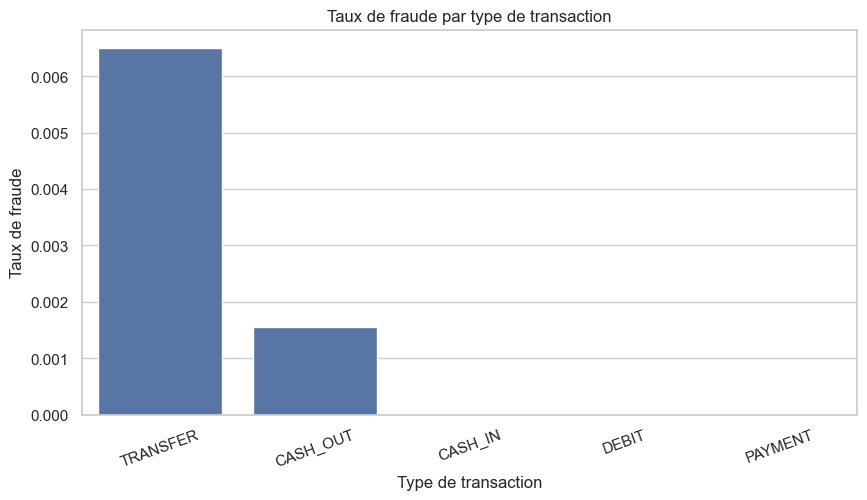

In [5]:
fraud_by_type = (
    df.groupby("type")["isFraud"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "n_transactions", "sum": "n_fraudes", "mean": "taux_fraude"})
    .sort_values("taux_fraude", ascending=False)
)

display(fraud_by_type)

ax = sns.barplot(x=fraud_by_type.index, y=fraud_by_type["taux_fraude"].values)
ax.set_title("Taux de fraude par type de transaction")
ax.set_xlabel("Type de transaction")
ax.set_ylabel("Taux de fraude")
plt.xticks(rotation=20)
plt.show()

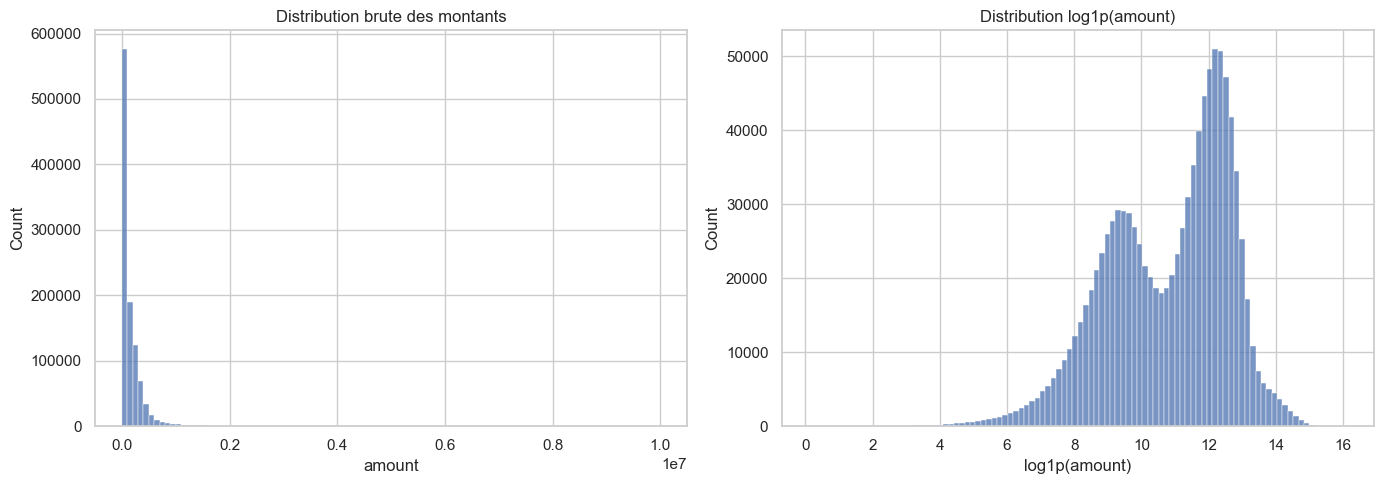

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,1047433.0,1.575397e+05,2.541883e+05,0.1,12134.87,76214.97,2.134928e+05,6419835.27
1,1142.0,1.192629e+06,2.030599e+06,119.0,86070.17,353179.45,1.248759e+06,10000000.00


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["amount"], bins=100, ax=axes[0])
axes[0].set_title("Distribution brute des montants")
axes[0].set_xlabel("amount")

sns.histplot(np.log1p(df["amount"]), bins=100, ax=axes[1])
axes[1].set_title("Distribution log1p(amount)")
axes[1].set_xlabel("log1p(amount)")

plt.tight_layout()
plt.show()

fraud_amount_stats = df.groupby("isFraud")["amount"].describe()
display(fraud_amount_stats)

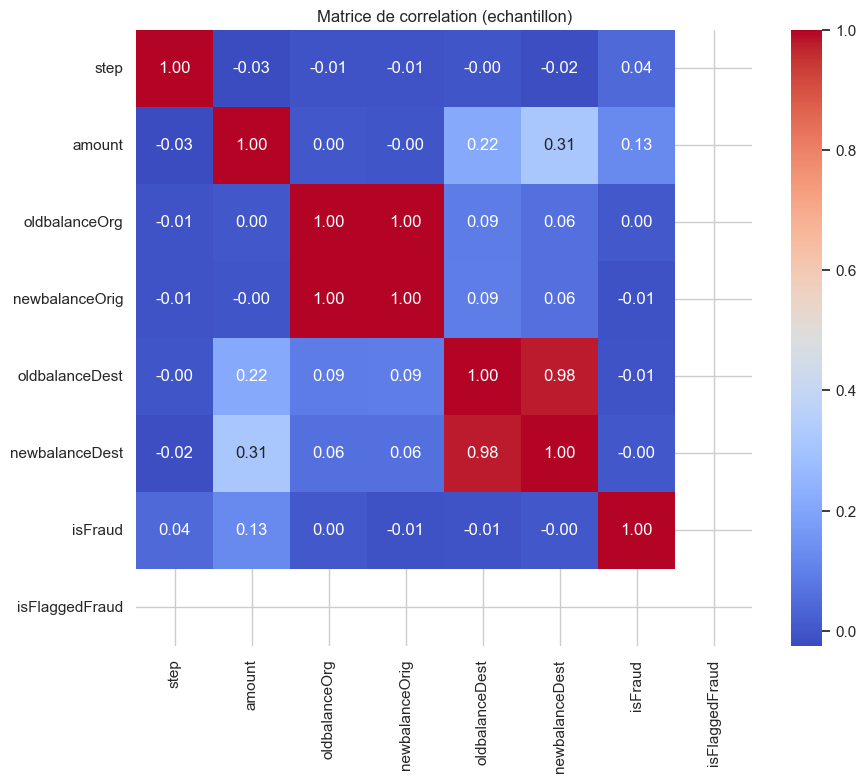

In [7]:
sample_size = min(len(df), 200000)
df_sample = df.sample(sample_size, random_state=42)

num_cols = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud",
]

corr = df_sample[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matrice de correlation (echantillon)")
plt.show()

In [8]:
origin_inconsistency = (df["oldbalanceOrg"] - df["amount"] != df["newbalanceOrig"]).mean()
dest_inconsistency = (df["oldbalanceDest"] + df["amount"] != df["newbalanceDest"]).mean()

print(f"Part des incoherences cote emetteur: {origin_inconsistency:.4f}")
print(f"Part des incoherences cote destinataire: {dest_inconsistency:.4f}")

tmp = df.copy()
tmp["origin_error"] = tmp["oldbalanceOrg"] - tmp["newbalanceOrig"] - tmp["amount"]
tmp["dest_error"] = tmp["newbalanceDest"] - tmp["oldbalanceDest"] - tmp["amount"]

display(tmp.groupby("isFraud")[["origin_error", "dest_error"]].describe().T)

Part des incoherences cote emetteur: 0.8444
Part des incoherences cote destinataire: 0.8076


isFraud                        0             1
origin_error count  1.047433e+06  1.142000e+03
             mean  -1.786522e+05 -7.917129e+03
             std    2.812532e+05  8.543744e+04
             min   -6.388051e+06 -1.933921e+06
             25%   -2.520368e+05  0.000000e+00
             50%   -6.852954e+04  0.000000e+00
             75%   -1.586570e+03  0.000000e+00
             max    1.000000e-02  2.328306e-10
dest_error   count  1.047433e+06  1.142000e+03
             mean  -2.203963e+04 -5.674886e+05
             std    4.293258e+05  1.593721e+06
             min   -1.319123e+07 -1.000000e+07
             25%   -3.147490e+04 -3.532465e+05
             50%   -4.269230e+03 -8.381980e+03
             75%    0.000000e+00  0.000000e+00
             max    3.514216e+07  8.875516e+06

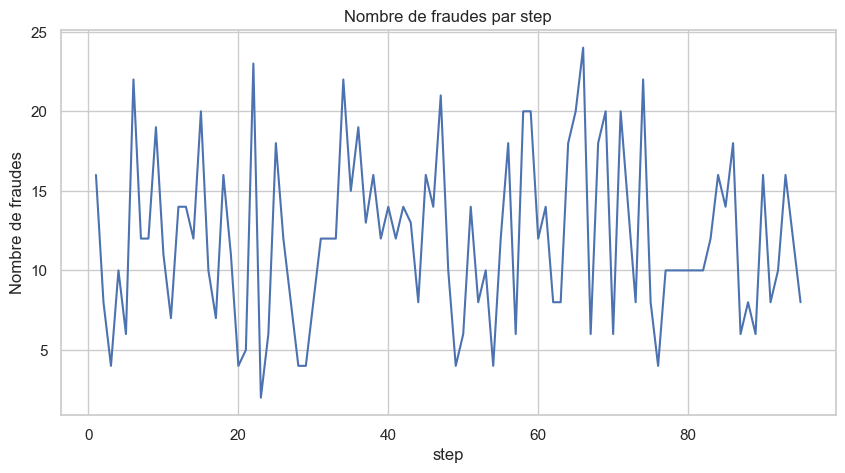

In [9]:
fraud_over_time = df.groupby("step")["isFraud"].sum().reset_index(name="n_fraudes")

ax = sns.lineplot(data=fraud_over_time, x="step", y="n_fraudes")
ax.set_title("Nombre de fraudes par step")
ax.set_xlabel("step")
ax.set_ylabel("Nombre de fraudes")
plt.show()

## Conclusion EDA fraude

- Le déséquilibre de classes est extrême : privilégier `PR-AUC`, `Recall` et le choix de seuil.
- Les types `TRANSFER` et `CASH_OUT` concentrent la fraude : variable `type` critique.
- Les incohérences de solde portent de l'information : features d'écart et d'erreur créées dans le pipeline.
- Les montants sont asymétriques : transformations log possibles pour certains modèles.
- Le signal temporel (`step`) peut aider ; une validation temporelle reste recommandée en production.

## Suite du projet

1. Notebook `02_modelisation_fraude.ipynb` — comparaison des modèles et métriques.
2. Script `src/models/train_fraud_model.py` — entraînement reproductible.
3. API `/predict/fraud` et dashboard — scoring en ligne.